In [1]:
import pandas as pd
df = pd.read_csv("/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/results/nov21.2/runs/p50.00_run01/ablation_predictions.csv")
# df = pd.read_csv("/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/results/sep24.3/p50.0_run1/ablation_predictions.csv")
df[(df["ablation"] == "subject") & (df["language"] == "nl")].iloc[:10]

,language,input,gold,prediction,ablation
131009,nl,le chien eet de wolf,de hond heeft de wolf gegeten,le chien a gegeten de gegeten,subject
131013,nl,le chien eet de wolven,de hond heeft de wolven gegeten,le chien a gegeten de gegeten,subject
131017,nl,les chiens eten de wolf,de honden hebben de wolf gegeten,les chiens ont gegeten de gegeten,subject
131021,nl,les chiens eten de wolven,de honden hebben de wolven gegeten,les chiens ont gegeten de gegeten,subject
131025,nl,le chien mag de wolf,de hond heeft de wolf gemogen,le chien a gemogen le wolf,subject
131029,nl,le chien mag de wolven,de hond heeft de wolven gemogen,le chien a gemogen le wolven,subject
131033,nl,les chiens mogen de wolf,de honden hebben de wolf gemogen,les chiens ont gemogen de gemogen,subject
131037,nl,les chiens mogen de wolven,de honden hebben de wolven gemogen,les chiens ont gemogen de gemogen,subject
131041,nl,le chien breekt de wolf,de hond heeft de wolf gebroken,le chien a gebroken de gebroken,subject
131045,nl,le chien breekt de wolven,de hond heeft de wolven gebroken,le chien a gebroken de gebroken,subject


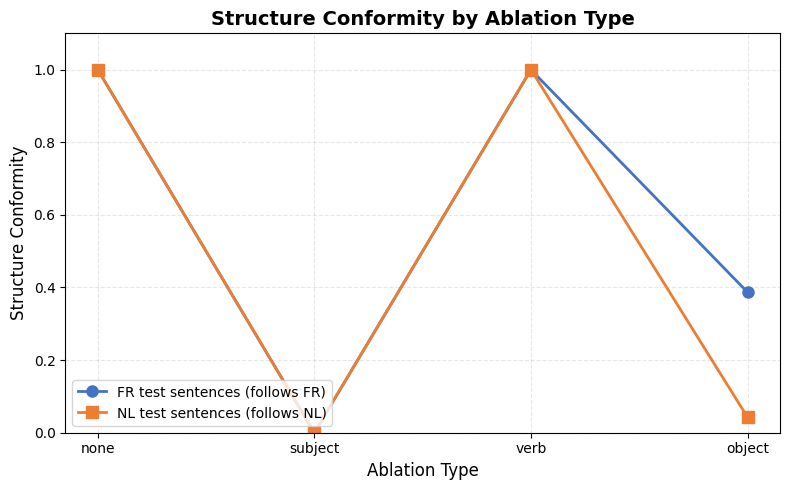

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

#results_dir = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/results/sep24.3/p50.0_run3"
results_dir = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/results/nov21.0/runs/p50.00_run01"
ablations = ['none', 'subject', 'verb', 'object']
fr_structure = []
nl_structure = []

for ablation in ablations:
    with open(f"{results_dir}/ablation_{ablation}_metrics.json") as f:
        metrics = json.load(f)
        fr_structure.append(metrics['fr_follows_fr'])
        nl_structure.append(metrics['nl_follows_nl'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ablations, fr_structure, marker='o', linewidth=2, markersize=8, label='FR test sentences (follows FR)', color='#4472C4')
ax.plot(ablations, nl_structure, marker='s', linewidth=2, markersize=8, label='NL test sentences (follows NL)', color='#ED7D31')

ax.set_xlabel('Ablation Type', fontsize=12)
ax.set_ylabel('Structure Conformity', fontsize=12)
ax.set_title('Structure Conformity by Ablation Type', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

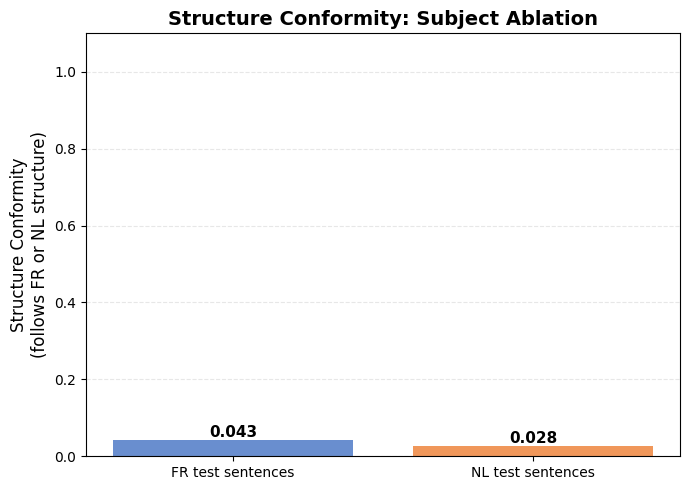


Structure Conformity for SUBJECT ablation:
(Follows either FR or NL structure)
--------------------------------------------------
FR test sentences: 0.043
  (FR structure: 0.000 + NL structure: 0.043)
NL test sentences: 0.028
  (FR structure: 0.028 + NL structure: 0.000)


In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Choose ablation type
ablation_type = "subject"  # Options: 'none', 'subject', 'verb', 'object'

# Load metrics for selected ablation
with open(f"{results_dir}/ablation_{ablation_type}_metrics.json") as f:
    metrics = json.load(f)

# Calculate structure conformity as sum (follows FR or NL structure)
fr_structure_conformity = metrics['fr_follows_fr'] + metrics['fr_follows_nl']
nl_structure_conformity = metrics['nl_follows_fr'] + metrics['nl_follows_nl']

# Create plot
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['FR test sentences', 'NL test sentences']
conformity_values = [fr_structure_conformity, nl_structure_conformity]

bars = ax.bar(categories, conformity_values, alpha=0.8, color=['#4472C4', '#ED7D31'])

ax.set_ylabel('Structure Conformity\n(follows FR or NL structure)', fontsize=12)
ax.set_title(f'Structure Conformity: {ablation_type.capitalize()} Ablation', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(1.1, max(conformity_values) * 1.1)])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, value in zip(bars, conformity_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nStructure Conformity for {ablation_type.upper()} ablation:")
print("(Follows either FR or NL structure)")
print("-" * 50)
print(f"FR test sentences: {fr_structure_conformity:.3f}")
print(f"  (FR structure: {metrics['fr_follows_fr']:.3f} + NL structure: {metrics['fr_follows_nl']:.3f})")
print(f"NL test sentences: {nl_structure_conformity:.3f}")
print(f"  (FR structure: {metrics['nl_follows_fr']:.3f} + NL structure: {metrics['nl_follows_nl']:.3f})")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Parameters
run_id = 1
prop = 0.5  # FR proportion
eval_prop = 0.05

# Paths
data_dir = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data"

# Load data
train_df_full = pd.read_csv(f"{data_dir}/train.csv")
test_df_full = pd.read_csv(f"{data_dir}/test.csv")

print("=" * 80)
print("STEP 1: Initial Data")
print("=" * 80)
print(f"Full train: {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")
print(f"Test: {len(test_df_full):,} total | "
      f"FR: {(test_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(test_df_full['lang'] == 'nl').sum():,}")

# STEP 1.5: Balance initial dataset FIRST - keep min(FR_count, NL_count) from each language
print("\n" + "=" * 80)
print("STEP 2: Balance Initial Dataset (keep min of FR/NL)")
print("=" * 80)
rng = np.random.RandomState(run_id)
fr_count = (train_df_full['lang'] == 'fr').sum()
nl_count = (train_df_full['lang'] == 'nl').sum()
min_count = min(fr_count, nl_count)

print(f"FR count: {fr_count:,} | NL count: {nl_count:,} | Min: {min_count:,}")

# Sample min_count from each language
fr_df = train_df_full[train_df_full['lang'] == 'fr'].sample(n=min_count, random_state=run_id)
nl_df = train_df_full[train_df_full['lang'] == 'nl'].sample(n=min_count, random_state=run_id)

train_df_full = pd.concat([fr_df, nl_df], ignore_index=True).reset_index(drop=True)

print(f"Balanced train: {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")

# STEP 3: Create stratified validation split (on balanced data)
print("\n" + "=" * 80)
print("STEP 3: Stratified Validation Split (on balanced data)")
print("=" * 80)
train_df_full, val_df = train_test_split(
    train_df_full,
    test_size=eval_prop,
    random_state=run_id,
    shuffle=True,
    stratify=train_df_full['lang']
)
train_df_full = train_df_full.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Validation: {len(val_df):,} total | "
      f"FR: {(val_df['lang'] == 'fr').sum():,} | "
      f"NL: {(val_df['lang'] == 'nl').sum():,}")
print(f"Training pool (after val split): {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")

# STEP 4: Apply global_key to training data only
print("\n" + "=" * 80)
print("STEP 4: Apply global_key to Training Data Only")
print("=" * 80)
train_df_full["global_key"] = rng.random(len(train_df_full))
train_df_full["orig_idx"] = np.arange(len(train_df_full))

# Create lang_rank for proportion selection
train_df_full["lang_rank"] = (
    train_df_full.groupby("lang")["global_key"]
                .rank(method="first")
                .astype(int)
)

# STEP 5: Select examples by proportion
total_budget = min(
    (train_df_full.lang == "fr").sum(),
    (train_df_full.lang == "nl").sum()
)

want_fr = int(total_budget * prop)
want_nl = total_budget - want_fr

fr_take = train_df_full[
    (train_df_full.lang == "fr") & (train_df_full.lang_rank <= want_fr)
]
nl_take = train_df_full[
    (train_df_full.lang == "nl") & (train_df_full.lang_rank <= want_nl)
]

print(f"Selected FR: {len(fr_take):,} | NL: {len(nl_take):,}")

# STEP 6: Shuffle training data (instead of sorting by global_key)
print("\n" + "=" * 80)
print("STEP 5: Shuffle Training Data")
print("=" * 80)
train_df = (
    pd.concat([fr_take, nl_take], ignore_index=True)
    .sample(frac=1, random_state=run_id)
    .reset_index(drop=True)
)

# Final summary
print("\n" + "=" * 80)
print("FINAL RESULTS - Language Distribution in Each Set")
print("=" * 80)

print("\nTRAINING SET:")
print(f"  Total: {len(train_df):,}")
print(f"  FR: {(train_df['lang'] == 'fr').sum():,} ({(train_df['lang'] == 'fr').sum()/len(train_df)*100:.2f}%)")
print(f"  NL: {(train_df['lang'] == 'nl').sum():,} ({(train_df['lang'] == 'nl').sum()/len(train_df)*100:.2f}%)")

print("\nVALIDATION SET:")
print(f"  Total: {len(val_df):,}")
print(f"  FR: {(val_df['lang'] == 'fr').sum():,} ({(val_df['lang'] == 'fr').sum()/len(val_df)*100:.2f}%)")
print(f"  NL: {(val_df['lang'] == 'nl').sum():,} ({(val_df['lang'] == 'nl').sum()/len(val_df)*100:.2f}%)")

print("\nTEST SET:")
print(f"  Total: {len(test_df_full):,}")
print(f"  FR: {(test_df_full['lang'] == 'fr').sum():,} ({(test_df_full['lang'] == 'fr').sum()/len(test_df_full)*100:.2f}%)")
print(f"  NL: {(test_df_full['lang'] == 'nl').sum():,} ({(test_df_full['lang'] == 'nl').sum()/len(test_df_full)*100:.2f}%)")

print("\n" + "=" * 80)
print("Summary:")
print(f"  Initial examples discarded for balancing: {(fr_count + nl_count) - (min_count * 2):,}")
print(f"  Training examples discarded after proportion selection: {len(train_df_full) - len(train_df):,}")
if len(train_df_full) > len(train_df):
    print(f"  Training FR discarded: {(train_df_full['lang'] == 'fr').sum() - (train_df['lang'] == 'fr').sum():,}")
    print(f"  Training NL discarded: {(train_df_full['lang'] == 'nl').sum() - (train_df['lang'] == 'nl').sum():,}")
print("=" * 80)


STEP 1: Initial Data
Full train: 525,872 total | FR: 265,696 | NL: 260,176
Test: 131,376 total | FR: 62,928 | NL: 68,448

STEP 2: Balance Initial Dataset (keep min of FR/NL)
FR count: 265,696 | NL count: 260,176 | Min: 260,176
Balanced train: 520,352 total | FR: 260,176 | NL: 260,176

STEP 3: Stratified Validation Split (on balanced data)
Validation: 26,018 total | FR: 13,009 | NL: 13,009
Training pool (after val split): 494,334 total | FR: 247,167 | NL: 247,167

STEP 4: Apply global_key to Training Data Only
Selected FR: 123,583 | NL: 123,584

STEP 5: Shuffle Training Data

FINAL RESULTS - Language Distribution in Each Set

TRAINING SET:
  Total: 247,167
  FR: 123,583 (50.00%)
  NL: 123,584 (50.00%)

VALIDATION SET:
  Total: 26,018
  FR: 13,009 (50.00%)
  NL: 13,009 (50.00%)

TEST SET:
  Total: 131,376
  FR: 62,928 (47.90%)
  NL: 68,448 (52.10%)

Summary:
  Initial examples discarded for balancing: 5,520
  Training examples discarded after proportion selection: 247,167
  Training FR d

In [ ]:
### fix the data loading portion to only have min of fr and nl on both test and train
### and also put a global order only on train and have stratified val taking
### until the train_lang_distribution.png looks fixed

### also redo the data creation and see why there is an imbalance in the num of samples at all.

# try sunny's hyperparams and some other ones.

In [ ]:
# nov 20

In [2]:
import json

lexicon_path = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data/lexicon_sep22.json"
lexicon = json.load(open(lexicon_path))

# Count nouns and verbs per language
fr_nouns = list(lexicon["NOUNS"]["fr"].keys())
nl_nouns = list(lexicon["NOUNS"]["nl"].keys())
fr_verbs = list(lexicon["VERBS"]["fr"].keys())
nl_verbs = list(lexicon["VERBS"]["nl"].keys())

print("=" * 80)
print("LEXICON COUNTS")
print("=" * 80)
print(f"\nNOUNS:")
print(f"  FR: {len(fr_nouns)} nouns")
print(f"  NL: {len(nl_nouns)} nouns")
print(f"  Difference: {abs(len(fr_nouns) - len(nl_nouns))} nouns")

print(f"\nVERBS:")
print(f"  FR: {len(fr_verbs)} verbs")
print(f"  NL: {len(nl_verbs)} verbs")
print(f"  Difference: {abs(len(fr_verbs) - len(nl_verbs))} verbs")

# Calculate expected dataset sizes
# For each (lang, subj, obj, verb) where subj != obj, we create 4 variations
# So: nouns × (nouns-1) × verbs × 4

fr_combinations = len(fr_nouns) * (len(fr_nouns) - 1) * len(fr_verbs) * 4
nl_combinations = len(nl_nouns) * (len(nl_nouns) - 1) * len(nl_verbs) * 4

print(f"\nEXPECTED DATASET SIZES (before split):")
print(f"  FR combinations: {fr_combinations:,}")
print(f"    Formula: {len(fr_nouns)} nouns × {len(fr_nouns)-1} objects × {len(fr_verbs)} verbs × 4 variations")
print(f"  NL combinations: {nl_combinations:,}")
print(f"    Formula: {len(nl_nouns)} nouns × {len(nl_nouns)-1} objects × {len(nl_verbs)} verbs × 4 variations")
print(f"  Total: {fr_combinations + nl_combinations:,}")
print(f"  Imbalance: {abs(fr_combinations - nl_combinations):,} examples ({abs(fr_combinations - nl_combinations)/(fr_combinations + nl_combinations)*100:.2f}%)")

# Unique (lang, subj, verb) pairs
fr_unique_pairs = len(fr_nouns) * len(fr_verbs)
nl_unique_pairs = len(nl_nouns) * len(nl_verbs)

print(f"\nUNIQUE (lang, subj, verb) PAIRS:")
print(f"  FR pairs: {fr_unique_pairs:,}")
print(f"  NL pairs: {nl_unique_pairs:,}")
print(f"  Total pairs: {fr_unique_pairs + nl_unique_pairs:,}")

# If split 20% to test
test_size = 0.2
fr_test_pairs = int(fr_unique_pairs * test_size)
nl_test_pairs = int(nl_unique_pairs * test_size)

print(f"\nEXPECTED AFTER 20% SPLIT:")
print(f"  FR test: {fr_test_pairs:,} pairs × 4 = {fr_test_pairs * 4:,} rows")
print(f"  NL test: {nl_test_pairs:,} pairs × 4 = {nl_test_pairs * 4:,} rows")
print(f"  Total test: {fr_test_pairs * 4 + nl_test_pairs * 4:,} rows")
print(f"  Imbalance in test: {abs(fr_test_pairs * 4 - nl_test_pairs * 4):,} rows")
print("=" * 80)

LEXICON COUNTS

NOUNS:
  FR: 47 nouns
  NL: 47 nouns
  Difference: 0 nouns

VERBS:
  FR: 38 verbs
  NL: 38 verbs
  Difference: 0 verbs

EXPECTED DATASET SIZES (before split):
  FR combinations: 328,624
    Formula: 47 nouns × 46 objects × 38 verbs × 4 variations
  NL combinations: 328,624
    Formula: 47 nouns × 46 objects × 38 verbs × 4 variations
  Total: 657,248
  Imbalance: 0 examples (0.00%)

UNIQUE (lang, subj, verb) PAIRS:
  FR pairs: 1,786
  NL pairs: 1,786
  Total pairs: 3,572

EXPECTED AFTER 20% SPLIT:
  FR test: 357 pairs × 4 = 1,428 rows
  NL test: 357 pairs × 4 = 1,428 rows
  Total test: 2,856 rows
  Imbalance in test: 0 rows


In [1]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path("/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/src").parent))

from src.dataset_manager import DatasetManager
from src.model_config import ModelConfig

# Paths
data_dir = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data"
lexicon_path = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data/lexicon_sep22.json"

# Create a minimal ModelConfig (required fields only - values don't matter for data generation)
config = ModelConfig(
    n_layer=2,
    n_head=2,
    n_embd=128,
    batch_size=16,
    learning_rate=1e-4,
    warmup_steps=100,
    weight_decay=0.01,
    eval_steps=100
)

# Initialize DatasetManager
dm = DatasetManager(data_dir, config, lexicon_path)

# Generate and save train/test data
print("Generating training and test data...")
train_df, test_df = dm.make_and_save_testing_and_training_data(
    test_size=0.1,  # 20% for test, 80% for train
    random_seed=0
)

print(f"\nGenerated data:")
print(f"  Training examples: {len(train_df):,}")
print(f"  Test examples: {len(test_df):,}")
print(f"  Total examples: {len(train_df) + len(test_df):,}")

# Show language distribution
print(f"\nTraining set language distribution:")
print(f"  FR: {(train_df['lang'] == 'fr').sum():,} ({(train_df['lang'] == 'fr').sum()/len(train_df)*100:.2f}%)")
print(f"  NL: {(train_df['lang'] == 'nl').sum():,} ({(train_df['lang'] == 'nl').sum()/len(train_df)*100:.2f}%)")

print(f"\nTest set language distribution:")
print(f"  FR: {(test_df['lang'] == 'fr').sum():,} ({(test_df['lang'] == 'fr').sum()/len(test_df)*100:.2f}%)")
print(f"  NL: {(test_df['lang'] == 'nl').sum():,} ({(test_df['lang'] == 'nl').sum()/len(test_df)*100:.2f}%)")

print(f"\nData saved to:")
print(f"  {data_dir}/train.csv")
print(f"  {data_dir}/test.csv")

/n/home06/drooryck/envs/codeswitching-py310/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Generating training and test data...

Generated data:
  Training examples: 591,744
  Test examples: 65,504
  Total examples: 657,248

Training set language distribution:
  FR: 295,872 (50.00%)
  NL: 295,872 (50.00%)

Test set language distribution:
  FR: 32,752 (50.00%)
  NL: 32,752 (50.00%)

Data saved to:
  /n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data/train.csv
  /n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data/test.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Parameters
run_id = 1
prop = 0.5  # FR proportion
eval_prop = 0.05

# Paths
data_dir = "/n/home06/drooryck/codeswitching-llms/july_aug_sept_exp/data"

# Load data
train_df_full = pd.read_csv(f"{data_dir}/train.csv")
test_df_full = pd.read_csv(f"{data_dir}/test.csv")

print("=" * 80)
print("STEP 1: Initial Data")
print("=" * 80)
print(f"Full train: {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")
print(f"Test: {len(test_df_full):,} total | "
      f"FR: {(test_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(test_df_full['lang'] == 'nl').sum():,}")

# STEP 1.5: Balance initial dataset FIRST - keep min(FR_count, NL_count) from each language
print("\n" + "=" * 80)
print("STEP 2: Balance Initial Dataset (keep min of FR/NL)")
print("=" * 80)
rng = np.random.RandomState(run_id)
fr_count = (train_df_full['lang'] == 'fr').sum()
nl_count = (train_df_full['lang'] == 'nl').sum()
min_count = min(fr_count, nl_count)

print(f"FR count: {fr_count:,} | NL count: {nl_count:,} | Min: {min_count:,}")

# Sample min_count from each language
fr_df = train_df_full[train_df_full['lang'] == 'fr'].sample(n=min_count, random_state=run_id)
nl_df = train_df_full[train_df_full['lang'] == 'nl'].sample(n=min_count, random_state=run_id)

train_df_full = pd.concat([fr_df, nl_df], ignore_index=True).reset_index(drop=True)

print(f"Balanced train: {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")

# STEP 3: Create stratified validation split (on balanced data)
print("\n" + "=" * 80)
print("STEP 3: Stratified Validation Split (on balanced data)")
print("=" * 80)
train_df_full, val_df = train_test_split(
    train_df_full,
    test_size=eval_prop,
    random_state=run_id,
    shuffle=True,
    stratify=train_df_full['lang']
)
train_df_full = train_df_full.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Validation: {len(val_df):,} total | "
      f"FR: {(val_df['lang'] == 'fr').sum():,} | "
      f"NL: {(val_df['lang'] == 'nl').sum():,}")
print(f"Training pool (after val split): {len(train_df_full):,} total | "
      f"FR: {(train_df_full['lang'] == 'fr').sum():,} | "
      f"NL: {(train_df_full['lang'] == 'nl').sum():,}")

# STEP 4: Apply global_key to training data only
print("\n" + "=" * 80)
print("STEP 4: Apply global_key to Training Data Only")
print("=" * 80)
train_df_full["global_key"] = rng.random(len(train_df_full))
train_df_full["orig_idx"] = np.arange(len(train_df_full))

# Create lang_rank for proportion selection
train_df_full["lang_rank"] = (
    train_df_full.groupby("lang")["global_key"]
                .rank(method="first")
                .astype(int)
)

# STEP 5: Select examples by proportion
total_budget = min(
    (train_df_full.lang == "fr").sum(),
    (train_df_full.lang == "nl").sum()
)

want_fr = int(total_budget * prop)
want_nl = total_budget - want_fr

fr_take = train_df_full[
    (train_df_full.lang == "fr") & (train_df_full.lang_rank <= want_fr)
]
nl_take = train_df_full[
    (train_df_full.lang == "nl") & (train_df_full.lang_rank <= want_nl)
]

print(f"Selected FR: {len(fr_take):,} | NL: {len(nl_take):,}")

# STEP 6: Shuffle training data (instead of sorting by global_key)
print("\n" + "=" * 80)
print("STEP 5: Shuffle Training Data")
print("=" * 80)
train_df = (
    pd.concat([fr_take, nl_take], ignore_index=True)
    .sample(frac=1, random_state=run_id)
    .reset_index(drop=True)
)

# Final summary
print("\n" + "=" * 80)
print("FINAL RESULTS - Language Distribution in Each Set")
print("=" * 80)

print("\nTRAINING SET:")
print(f"  Total: {len(train_df):,}")
print(f"  FR: {(train_df['lang'] == 'fr').sum():,} ({(train_df['lang'] == 'fr').sum()/len(train_df)*100:.2f}%)")
print(f"  NL: {(train_df['lang'] == 'nl').sum():,} ({(train_df['lang'] == 'nl').sum()/len(train_df)*100:.2f}%)")

print("\nVALIDATION SET:")
print(f"  Total: {len(val_df):,}")
print(f"  FR: {(val_df['lang'] == 'fr').sum():,} ({(val_df['lang'] == 'fr').sum()/len(val_df)*100:.2f}%)")
print(f"  NL: {(val_df['lang'] == 'nl').sum():,} ({(val_df['lang'] == 'nl').sum()/len(val_df)*100:.2f}%)")

print("\nTEST SET:")
print(f"  Total: {len(test_df_full):,}")
print(f"  FR: {(test_df_full['lang'] == 'fr').sum():,} ({(test_df_full['lang'] == 'fr').sum()/len(test_df_full)*100:.2f}%)")
print(f"  NL: {(test_df_full['lang'] == 'nl').sum():,} ({(test_df_full['lang'] == 'nl').sum()/len(test_df_full)*100:.2f}%)")

print("\n" + "=" * 80)
print("Summary:")
print(f"  Initial examples discarded for balancing: {(fr_count + nl_count) - (min_count * 2):,}")
print(f"  Training examples discarded after proportion selection: {len(train_df_full) - len(train_df):,}")
if len(train_df_full) > len(train_df):
    print(f"  Training FR discarded: {(train_df_full['lang'] == 'fr').sum() - (train_df['lang'] == 'fr').sum():,}")
    print(f"  Training NL discarded: {(train_df_full['lang'] == 'nl').sum() - (train_df['lang'] == 'nl').sum():,}")
print("=" * 80)


STEP 1: Initial Data
Full train: 591,744 total | FR: 295,872 | NL: 295,872
Test: 65,504 total | FR: 32,752 | NL: 32,752

STEP 2: Balance Initial Dataset (keep min of FR/NL)
FR count: 295,872 | NL count: 295,872 | Min: 295,872
Balanced train: 591,744 total | FR: 295,872 | NL: 295,872

STEP 3: Stratified Validation Split (on balanced data)
Validation: 29,588 total | FR: 14,794 | NL: 14,794
Training pool (after val split): 562,156 total | FR: 281,078 | NL: 281,078

STEP 4: Apply global_key to Training Data Only
Selected FR: 140,539 | NL: 140,539

STEP 5: Shuffle Training Data

FINAL RESULTS - Language Distribution in Each Set

TRAINING SET:
  Total: 281,078
  FR: 140,539 (50.00%)
  NL: 140,539 (50.00%)

VALIDATION SET:
  Total: 29,588
  FR: 14,794 (50.00%)
  NL: 14,794 (50.00%)

TEST SET:
  Total: 65,504
  FR: 32,752 (50.00%)
  NL: 32,752 (50.00%)

Summary:
  Initial examples discarded for balancing: 0
  Training examples discarded after proportion selection: 281,078
  Training FR discard

In [ ]:
## rich metrics trainer callbacks on a new run see if earlier, the model does more logical things on ablated sentences
## try a run for 3 epochs -- doesnt help
## try a new method that doesnt do any fancy data splitting and tries to have the hyperparams from sep24.3
## we literally patch in the code from a previous commit for rnu_single but still get a different kind of model.